In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import sklearn as sk
import numpy as np


In [43]:
# import required packages or libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [44]:
df=pd.read_csv("Social_Network_Ads.csv")
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [46]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

<Axes: >

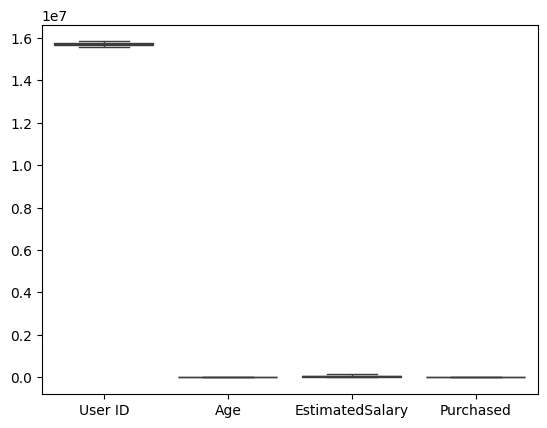

In [47]:
sns.boxplot(data=df)

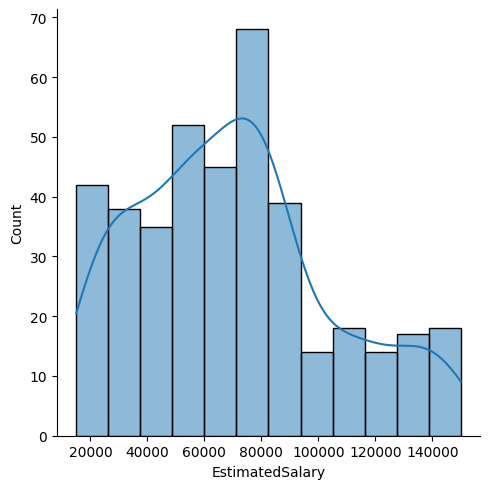

In [48]:
sns.displot(data=df.EstimatedSalary,kde=True)

In [49]:
x=np.asarray(df[['Age','EstimatedSalary']])
y=np.asarray(df[['Purchased']])

x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.3)

In [50]:
model=LogisticRegression()
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)
model.fit(x_train,y_train.ravel())

LogisticRegression()

In [51]:

y_pred = model.predict(x_test)

#  Create the matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


# Check accuracy percentage
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100}%")

Confusion Matrix:
[[168  14]
 [ 29  69]]
Accuracy: 84.64285714285714%


In [52]:
#  Extract TP, FP, TN, FN
# In a 2x2 matrix: [ [TN, FP], [FN, TP] ]
tn = cm[0, 0]
fp = cm[0, 1]
fn = cm[1, 0]
tp = cm[1, 1]

#  Compute Metrics
total = tn + fp + fn + tp
accuracy = (tp+ tn) / total
error_rate = (fp + fn) / total
precision = tp / (tp + fp) if (tp+fp) != 0 else 0  # Also known as Precision

# Print Results
print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print("-" * 30)
print(f"Accuracy: {accuracy:.2f}")
print(f"Error Rate: {error_rate:.2f}")
print(f"Precision: {precision:.2f}")

True Positives (TP): 69
True Negatives (TN): 168
False Positives (FP): 14
False Negatives (FN): 29
------------------------------
Accuracy: 0.85
Error Rate: 0.15
Precision: 0.83
